In [41]:
import numpy as np
import pandas as pd # groupby mean 
import matplotlib.pyplot as plt # grid 
from numpy.typing import NDArray

# Game of Life

In [42]:
#
arr = np.array([[1,2,3], [4,5,6],[7,8,9]]) # 2D 
print("Shape    ", arr.shape) # (3,3) (rows, cols)
print("how many rows-horizontal:    ",arr.shape[0]) # how many rows 3
print("how many cols-vertical:      ",arr.shape[1]) # how many cols 3



Shape     (3, 3)
how many rows-horizontal:     3
how many cols-vertical:       3


In [43]:
# slicing
print(arr[0]) # 1,2,3
print(arr[:,0]) # 1,4,7
print(arr[1:,1:]) # 5,6,8,9 # Row 0 is not included

[1 2 3]
[1 4 7]
[[5 6]
 [8 9]]


In [44]:
#
arr2 = np.array([
    [1,2,3,4],
    [5,6,7,8],
    [9,10,11,12]])
print(arr2[1]) # 5,6,7,8
print(arr2[:,1]) # 2,6,10
print(arr2[1:, 2: ]) # 7,8    11,12


[5 6 7 8]
[ 2  6 10]
[[ 7  8]
 [11 12]]


[[0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]]
********************
[[0 0 0 0 0 0 0 0 0 0]
 [0 0 1 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]]
(10, 10)


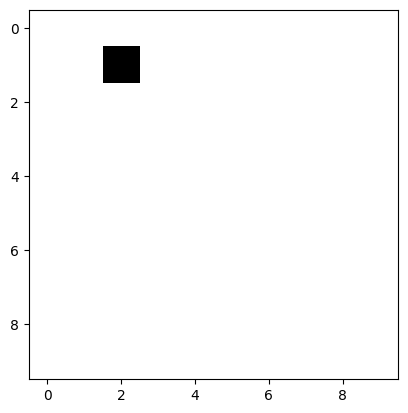

In [45]:
grid = np.zeros((10,10), dtype=int)
print(grid)
grid[1,2] = 1
print('*'*20)
print(grid)
plt.imshow(grid, cmap='binary')
print(grid.shape)

(10, 10)
int64


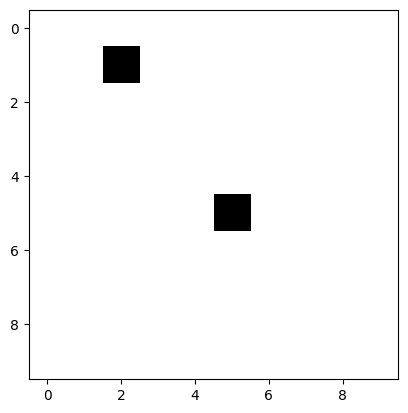

In [46]:
grid[5,5]= 1
plt.imshow(grid, cmap='binary')
print(grid.shape)
print(grid.dtype)

# Building a grid
### np.zeros((rows, cols), dtype=int) creates a blank grid; set cells with [row, col].

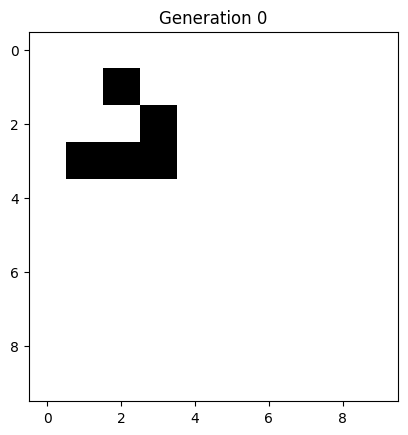

In [47]:
grid = np.zeros((10, 10), dtype=int)

# Glider
grid[1, 2] = 1
grid[2, 3] = 1
grid[3, 1] = 1
grid[3, 2] = 1
grid[3, 3] = 1

plt.imshow(grid, cmap='binary')
plt.title('Generation 0')
plt.show()

# step_naive — explicit loops
## Conway's rules: live cell survives with 2–3 neighbours; dead cell is born with exactly 3.

### np.zeros_like(grid) creates a blank array with the same shape and dtype — we build the next generation there so we never read from a half-updated grid.

In [48]:
# the current grid -> count neighbors -> rules -> new grid
def step_naive(grid: NDArray[np.int_]) -> NDArray[np.int_]:
    rows, cols = grid.shape
    new_grid = np.zeros_like(grid)

    for i in range(rows):
        for j in range(cols):
            neighbours = 0
            for di in (-1, 0, 1):
                for dj in (-1, 0, 1):
                    if di == 0 and dj == 0:
                        continue
                    ni, nj = i + di, j + dj
                    if 0 <= ni < rows and 0 <= nj < cols:
                        neighbours += grid[ni, nj]

            if grid[i, j] == 1 and neighbours in (2, 3):
                new_grid[i, j] = 1
            elif grid[i, j] == 0 and neighbours == 3:
                new_grid[i, j] = 1

    return new_grid

(10, 10)


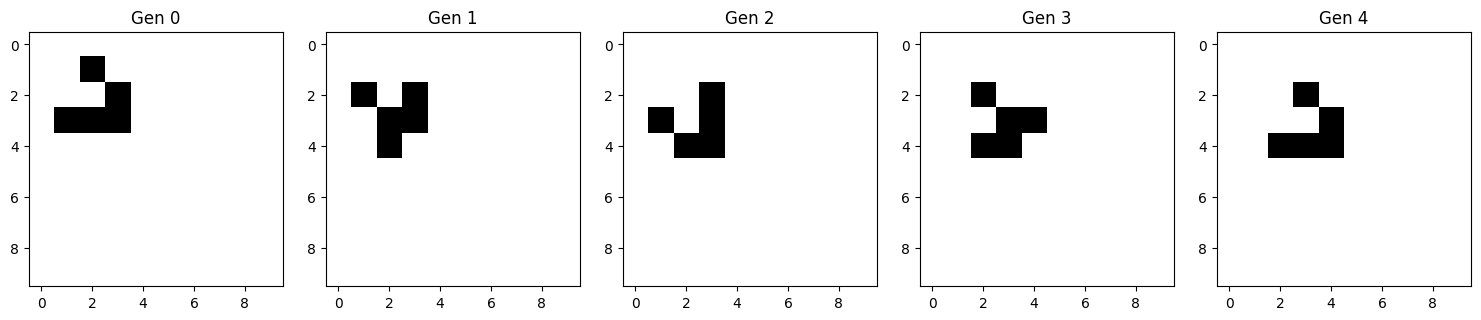

In [49]:
print(grid.shape)
g1 = step_naive(grid)
g2 = step_naive(g1)
g3 = step_naive(g2)
g4 = step_naive(g3)

fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for ax, g, title in zip(axes, [grid, g1, g2, g3, g4],
                              ['Gen 0', 'Gen 1', 'Gen 2', 'Gen 3', 'Gen 4']):
    ax.imshow(g, cmap='binary')
    ax.set_title(title)
plt.tight_layout()
plt.show()

# np.roll — circular shifting
### Shifts every element shift positions along an axis — elements that fall off one end wrap to the other. This is how we count all 8 neighbours at once without an explicit loop over cells.

In [50]:
arr = np.array([1, 2, 3, 4, 5])
print(np.roll(arr,  1))    # [5 1 2 3 4] — right, 5 wraps around
print(np.roll(arr, -1))    # [2 3 4 5 1] — left,  1 wraps around

[5 1 2 3 4]
[2 3 4 5 1]


In [51]:
test = np.array([[1, 2, 3],
                 [4, 5, 6],
                 [7, 8, 9]])

print(np.roll(test,  1, axis=0))   # shift rows down [[7 8 9], [1 2 3], [4 5 6]]
print()
print(np.roll(test,  1, axis=1))   # shift cols right [[3 2 1], [6 4 5], 9 7 8]

[[7 8 9]
 [1 2 3]
 [4 5 6]]

[[3 1 2]
 [6 4 5]
 [9 7 8]]


# Boolean arrays: & not and
### Use & for element-wise AND on NumPy arrays. and tries to collapse the whole array to a single bool — NumPy raises ValueError.

In [57]:
arr = np.array([1, 2, 3, 4, 5])

mask = (arr > 2) & (arr < 5)
print(mask)          # [False False  True  True False]
print(arr[mask])     # [3 4]

[False False  True  True False]
[3 4]


In [55]:

try:
    result = (arr > 2) and (arr < 5)
except ValueError as e:
    print(type(e).__name__, e)

ValueError The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()


#### Same rule: | not or for element-wise OR.

# step_fast — vectorized
### Shift the grid in all 8 directions and accumulate — one neighbour count array for the entire grid.

### UnboundLocalError: reading a variable before assigning it inside a loop crashes immediately. Fix: initialize neighbours to np.zeros_like(grid) before the loop.

In [58]:

# Bug: reads `neighbours` before it exists
def broken_step(grid):
    for di in (-1, 0, 1):
        for dj in (-1, 0, 1):
            if di == 0 and dj == 0:
                continue
            neighbours = neighbours + np.roll(np.roll(grid, di, axis=0), dj, axis=1)
    return neighbours

try:
    broken_step(np.ones((4, 4), dtype=int))
except UnboundLocalError as e:
    print(type(e).__name__, e)

UnboundLocalError cannot access local variable 'neighbours' where it is not associated with a value


In [59]:
def step_fast(grid: NDArray[np.int_]) -> NDArray[np.int_]:
    neighbours = np.zeros_like(grid)    # initialize before the loop
    for di in (-1, 0, 1):
        for dj in (-1, 0, 1):
            if di == 0 and dj == 0:
                continue
            neighbours = neighbours + np.roll(
                np.roll(grid, di, axis=0), dj, axis=1
            )
    is_born  = (grid == 0) & (neighbours == 3)
    survives = (grid == 1) & ((neighbours == 2) | (neighbours == 3))
    return (is_born | survives).astype(int)

# Verify and benchmark
### step_fast uses periodic (wrap-around) boundaries, step_naive uses fixed boundaries — they agree on interior cells only.

In [60]:
rng = np.random.default_rng(368)
test_grid = (rng.random((20, 20)) < 0.3).astype(int)

naive_result = step_naive(test_grid)
fast_result  = step_fast(test_grid)

print("Interior agrees:",
      np.array_equal(naive_result[1:-1, 1:-1], fast_result[1:-1, 1:-1]))
     

Interior agrees: True


In [61]:
rng = np.random.default_rng(42)
large_grid = (rng.random((200, 200)) < 0.3).astype(int)

print("Naive:")
%timeit step_naive(large_grid)
print("Fast:")
%timeit step_fast(large_grid)

Naive:
133 ms ± 929 μs per loop (mean ± std. dev. of 7 runs, 10 loops each)
Fast:
767 μs ± 62.9 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


# run_simulation
#### Run the simulation and log population at each generation.

### Two easy bugs to watch for:

- return inside the loop — exits on generation 0, log has one entry.
- Missing grid = step_fast(grid) inside the loop — simulates the same generation forever.
- np.random.default_rng(seed) guarantees the same grid for the same seed — experiments stay reproducible.

In [ ]:
def run_simulation(
    density: float,
    seed: int,
    grid_size: int = 100,
    max_generations: int = 500,
) -> list[dict]:
    rng: np.random.Generator = np.random.default_rng(seed)
    grid: NDArray[np.int_] = (
        rng.random((grid_size, grid_size)) < density
    ).astype(int)

    log: list[dict] = []

    for generation in range(max_generations):
        population = int(grid.sum()) # how many cells are alive?
        log.append({
            'density':    density,
            'seed':       seed,
            'generation': generation,
            'population': population,
        })
        if population == 0:
            break
        grid = step_fast(grid) # if we don't write this the generations would be the same forever

    return log   # outside the loop

In [67]:
log = run_simulation(density=0.30, seed=42) # 30% alive
print(f"Generations: {len(log)}")
print(f"First: {log[0]}")
print(f"Last:  {log[-1]}")

Generations: 500
First: {'density': 0.3, 'seed': 42, 'generation': 0, 'population': 3043}
Last:  {'density': 0.3, 'seed': 42, 'generation': 499, 'population': 606}


# run_experiment — pandas groupby
### Sweep over initial densities and seeds to see whether starting density affects where the population stabilizes.

### df.groupby(col) splits the DataFrame into one group per unique value; chain .mean(), .std(), etc.

In [68]:
def run_experiment(
    densities: list[float],
    num_seeds: int,
    grid_size: int = 100,
    max_generations: int = 500,
) -> pd.DataFrame:
    all_logs: list[dict] = []
    for density in densities:
        print(f"density {density:.2f}...")
        for seed in range(num_seeds):
            all_logs.extend(run_simulation(density, seed, grid_size, max_generations))
    return pd.DataFrame(all_logs)

In [70]:
DENSITIES       = [0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50]
NUM_SEEDS       = 20
GRID_SIZE       = 100
MAX_GENERATIONS = 500

df = run_experiment(
    densities=DENSITIES,
    num_seeds=NUM_SEEDS,
    grid_size=GRID_SIZE,
    max_generations=MAX_GENERATIONS,
)
print(f"\nTotal rows: {len(df)}")
df.head()

density 0.05...
density 0.10...
density 0.15...
density 0.20...
density 0.25...
density 0.30...
density 0.35...
density 0.40...
density 0.45...
density 0.50...

Total rows: 100000


,density,seed,generation,population
0,0.05,0,0,503
1,0.05,0,1,84
2,0.05,0,2,42
3,0.05,0,3,34
4,0.05,0,4,33


In [ ]:
# Average population over the last 50 generations per (density, seed)
# split - apply - combine
stationary = (
    df.groupby(['density', 'seed'])
      .tail(50)
      .groupby(['density', 'seed'])['population']
      .mean()
      .reset_index()
)
stationary['stationary_density'] = stationary['population'] / (GRID_SIZE ** 2)
stationary.head()

,density,seed,population,stationary_density
0,0.05,0,37.0,0.0037
1,0.05,1,24.0,0.0024
2,0.05,2,18.0,0.0018
3,0.05,3,52.0,0.0052
4,0.05,4,76.0,0.0076


In [72]:
summary = stationary.groupby('density')['stationary_density'].agg(['mean', 'std'])
summary

,mean,std
density,,
0.05,0.004517,0.003690
0.10,0.041458,0.009827
0.15,0.055237,0.010807
0.20,0.050602,0.010851
0.25,0.055674,0.011969
0.30,0.056636,0.012608
0.35,0.056178,0.012216
0.40,0.056557,0.012039
0.45,0.058832,0.010606


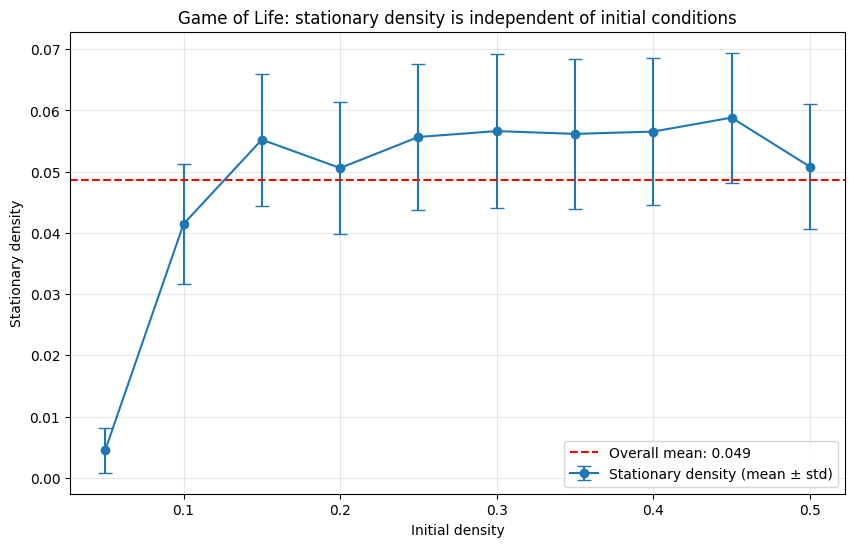

In [73]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.errorbar(
    summary.index,
    summary['mean'],
    yerr=summary['std'],
    marker='o',
    capsize=5,
    label='Stationary density (mean ± std)',
)
ax.axhline(
    y=summary['mean'].mean(),
    color='red', linestyle='--',
    label=f'Overall mean: {summary["mean"].mean():.3f}',
)
ax.set_xlabel('Initial density')
ax.set_ylabel('Stationary density')
ax.set_title('Game of Life: stationary density is independent of initial conditions')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()